# GEC Pretrained Classifier with 5-Fold Stratified Cross-Validation

In [1]:
import sys
sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection/model/architectures/GAAE')
sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection/model/architectures/GEC')

import os
import json
from datetime import datetime
from copy import deepcopy

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

import config
from models import GraphEncoderClassifierAttention
from dataset import ClassificationDataset, CombinedClassificationDataset
from utils import load_frozen_encoder_from_gaae, compute_class_weights, knn_binary_adjacency_matrix_no_diag
from train import train_classifier, evaluate_classifier

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [3]:
os.environ['WANDB_API_KEY'] = '24f49a72509540b42cb808a2a16ee55aedf93a65'
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = "gec-converter-classification"

wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
IN_FEATURES = 110
HIDDEN_DIM = 110
LATENT_DIM = 64
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.6
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30

KNN_K = 16
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'pearson'

FREEZE_ENCODER = False
CLASSIFICATION_THRESHOLD = 0.35

N_FOLDS = 5
RANDOM_STATE = 42

CONVERTER_LIST_PATH = config.DELCODE_ROOT + '/Delcode_patient_data/Delcode_converter_transition_times.csv'

In [5]:
checkpoint_dir = os.path.join(config.GAAE_DIR, "notebooks/checkpoints")
available_runs = [d for d in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, d))]
print("Available checkpoints:")
for i, run in enumerate(sorted(available_runs)):
    print(f"  {i}: {run}")

selected_run_index = int(input("Select a checkpoint by index: "))
RUN_NAME = sorted(available_runs)[selected_run_index]

Available checkpoints:
  0: atomic-deluge-41
  1: deep-morning-81
  2: driven-frost-37
  3: driven-water-76
  4: earnest-firefly-84
  5: earnest-flower-82
  6: fallen-cosmos-83
  7: fiery-wildflower-85
  8: fluent-mountain-43
  9: grateful-sky-87
  10: hopeful-cherry-86
  11: jolly-brook-93
  12: kind-pine-90
  13: rosy-eon-78
  14: run_2025-12-12_11-49-44
  15: spring-frog-40
  16: summer-microwave-39
  17: worldly-snowball-77


In [6]:
GAAE_CHECKPOINT_PATH = os.path.join(checkpoint_dir, RUN_NAME, f"model_{RUN_NAME}.pth")

## Load Datasets

In [7]:
converter_dataset = ClassificationDataset(
    root=config.DELCODE_CONVERTER_GRAPH_DATA,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=config.DELCODE_PATIENT_DATA,
    converter_list_path=CONVERTER_LIST_PATH,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE
)

mci_stable_dataset = ClassificationDataset(
    root=config.DELCODE_MCI_SCD_GRAPH_DATA,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=config.DELCODE_PATIENT_DATA,
    converter_list_path=CONVERTER_LIST_PATH,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE
)

print(f"Converter dataset size: {len(converter_dataset)}")
print(f"MCI Stable dataset size: {len(mci_stable_dataset)}")

Converter dataset size: 59
MCI Stable dataset size: 493


In [8]:
combined_dataset = CombinedClassificationDataset(converter_dataset, mci_stable_dataset)
all_labels = combined_dataset.get_labels()

print(f"\nCombined dataset:")
print(f"  Total samples: {len(combined_dataset)}")
print(f"  Converters: {sum(all_labels)} ({sum(all_labels)/len(all_labels)*100:.1f}%)")
print(f"  Non-converters: {len(all_labels) - sum(all_labels)} ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")


Combined dataset:
  Total samples: 552
  Converters: 59.0 (10.7%)
  Non-converters: 493.0 (89.3%)


## Load Splits from gec_data_splits.json

Train + Validation patients from the JSON are used as the CV pool.
Test patients from the JSON are the holdout set.

In [9]:
sys.path.insert(0, config.DELCODE_ROOT)
from load_splits import load_gec_splits, get_split_indices_for_dataset

gec_splits = load_gec_splits()

train_split_indices = get_split_indices_for_dataset(combined_dataset, gec_splits, "train")
val_split_indices = get_split_indices_for_dataset(combined_dataset, gec_splits, "validation")
test_split_indices = get_split_indices_for_dataset(combined_dataset, gec_splits, "test")

cv_indices = train_split_indices + val_split_indices
holdout_indices = test_split_indices

cv_labels = [all_labels[i] for i in cv_indices]
holdout_labels = [all_labels[i] for i in holdout_indices]

print(f"GEC Split Sizes (from gec_data_splits.json):")
print(f"  Train split: {len(train_split_indices)}")
print(f"  Validation split: {len(val_split_indices)}")
print(f"  Test split (holdout): {len(test_split_indices)}")
print(f"\nCV set: {len(cv_indices)} samples, {sum(cv_labels)} converters ({sum(cv_labels)/len(cv_labels)*100:.1f}%)")
print(f"Holdout set: {len(holdout_indices)} samples, {sum(holdout_labels)} converters ({sum(holdout_labels)/len(holdout_labels)*100:.1f}%)")

GEC Split Sizes (from gec_data_splits.json):
  Train split: 318
  Validation split: 106
  Test split (holdout): 106

CV set: 424 samples, 30.0 converters (7.1%)
Holdout set: 106 samples, 7.0 converters (6.6%)


## 5-Fold Stratified Cross-Validation

In [10]:
cv_results = {
    'fold': [],
    'val_loss': [],
    'val_auc': [],
    'val_sensitivity': [],
    'val_specificity': [],
    'val_f1': [],
    'best_threshold': [],
    'best_epoch': []
}

best_model_state = None
best_val_auc = 0
best_fold = -1

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting {N_FOLDS}-fold stratified cross-validation...")
print("=" * 60)

for fold, (train_idx_in_cv, val_idx_in_cv) in enumerate(skf.split(cv_indices, cv_labels)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    train_idx = [cv_indices[i] for i in train_idx_in_cv]
    val_idx = [cv_indices[i] for i in val_idx_in_cv]
    
    train_labels_fold = [all_labels[i] for i in train_idx]
    val_labels_fold = [all_labels[i] for i in val_idx]
    
    print(f"Train: {len(train_idx)} samples, {sum(train_labels_fold)} converters ({sum(train_labels_fold)/len(train_labels_fold)*100:.1f}%)")
    print(f"Val: {len(val_idx)} samples, {sum(val_labels_fold)} converters ({sum(val_labels_fold)/len(val_labels_fold)*100:.1f}%)")
    
    train_dataset = torch.utils.data.Subset(combined_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(combined_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    pos_weight = compute_class_weights(train_labels_fold, device=device)
    
    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN
    ).to(device)
    
    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()
    
    optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)
    
    fold_model_state, history = train_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        pos_weight=pos_weight,
        epochs=EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_save_path=None,
        project_name=WANDB_PROJECT
    )
    
    model.load_state_dict(fold_model_state)
    model.eval()
    
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            cond_vec = torch.stack([
                batch.patient_age,
                batch.patient_sex.float()
            ], dim=1).to(device)
            output, _ = model(batch.x, batch.edge_index, cond_vec, batch.batch)
            probs = torch.sigmoid(output).cpu().numpy()
            all_preds.extend(probs.flatten())
            all_targets.extend(batch.is_converter.cpu().numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
    fold_auc = auc(fpr, tpr)
    
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    
    binary_preds = (all_preds >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_targets, binary_preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    cv_results['fold'].append(fold + 1)
    cv_results['val_auc'].append(fold_auc)
    cv_results['val_sensitivity'].append(sensitivity)
    cv_results['val_specificity'].append(specificity)
    cv_results['val_f1'].append(f1)
    cv_results['best_threshold'].append(best_threshold)
    cv_results['best_epoch'].append(len(history['train_loss']))
    
    print(f"\nFold {fold+1} Results:")
    print(f"  AUC: {fold_auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Best Threshold: {best_threshold:.4f}")
    
    if fold_auc > best_val_auc:
        best_val_auc = fold_auc
        best_model_state = deepcopy(fold_model_state)
        best_fold = fold + 1
        best_threshold_overall = best_threshold
    
    try:
        wandb.finish()
    except Exception:
        pass

print(f"\n{'='*60}")
print("CROSS-VALIDATION COMPLETE")
print(f"{'='*60}")

Starting 5-fold stratified cross-validation...

FOLD 1/5
Train: 339 samples, 24.0 converters (7.1%)
Val: 85 samples, 6.0 converters (7.1%)


/mnt/e/smoteval/conda_envs/early_ad/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


/mnt/e/smoteval/conda_envs/early_ad/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 1 Results:
  AUC: 0.7785
  Sensitivity: 0.8333
  Specificity: 0.6835
  F1: 0.2778
  Best Threshold: 0.0001


...

/mnt/e/smoteval/conda_envs/early_ad/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 5 Results:
  AUC: 0.6603
  Sensitivity: 0.8333
  Specificity: 0.5897
  F1: 0.2326
  Best Threshold: 0.0011


learning_rate,██████████████████▃▃▃▃▃▃▁
train_acc,▁▄▇▇▇▇▇▇▇▇▇██████████████
train_auc,▁▂▃▄▅▅▅▅▅▆▇▆▇▇▇████▇█████
train_f1,▁▂▁▁▂▃▄▄▄▅▅▆▆▆▇▆▆▇▇▇▇▇▇██
train_loss,▅▅▆▅▇▇█▆▆▇▅▆▅█▄▂▃▃▃▆▃▃▃▂▁
val_acc,▁███▇███▇▆█▇█▇▇██████████
val_auc,▅▄▁▂▁▅▆▆▅▅██▇█▆▄▄▅▅▅▅▅▅▄▄
val_f1,▆▁▁▁▁▁▇▁▁▅▁▇▇▁▇▇▇▇██▇▇█▇▇
val_loss,▁▁▁▁▁▂▁▂▂▂▃▂▃▄▄▅▆▆▇▆▆▇█▇█
learning_rate,0.00025
train_acc,0.99412



CROSS-VALIDATION COMPLETE


## Cross-Validation Results Summary

In [11]:
print("\nCross-Validation Summary:")
print("="*60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f"\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}")
print(f"Best threshold: {best_threshold_overall:.4f}")


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.5924     0.1326     0.3861     0.7785
val_sensitivity          0.6333     0.2449     0.3333     0.8333
val_specificity          0.6850     0.2331     0.3038     0.9620
val_f1                   0.2522     0.0691     0.1515     0.3636

Best model from Fold 1 with AUC = 0.7785
Best threshold: 0.0001


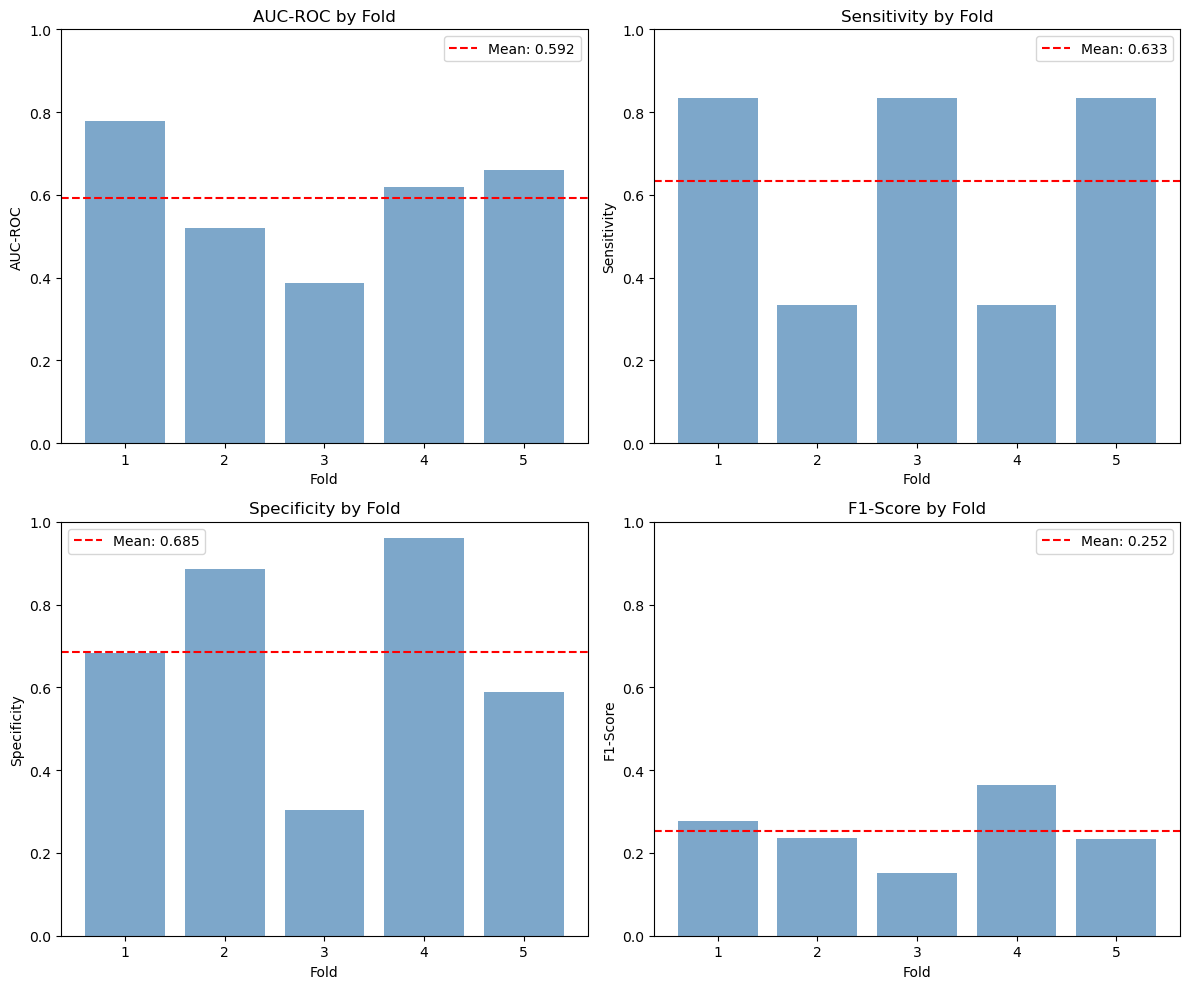

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']

for ax, metric, title in zip(axes.flat, metrics, titles):
    values = cv_results[metric]
    ax.bar(range(1, N_FOLDS+1), values, color='steelblue', alpha=0.7)
    ax.axhline(y=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Fold')
    ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(config.GEC_DIR, 'cv_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## Save Best Model and Results

In [14]:
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"cv_run_{run_timestamp}"
run_artifact_dir = os.path.join(config.GEC_DIR, "checkpoints", run_name)
os.makedirs(run_artifact_dir, exist_ok=True)

model_filename = f"best_model_fold{best_fold}.pth"
model_file = os.path.join(run_artifact_dir, model_filename)
torch.save(best_model_state, model_file)
print(f"Saved best model to {model_file}")

results_to_save = {
    'run_name': run_name,
    'timestamp': run_timestamp,
    'n_folds': N_FOLDS,
    'cv_results': cv_results,
    'cv_summary': {
        'auc_mean': float(np.mean(cv_results['val_auc'])),
        'auc_std': float(np.std(cv_results['val_auc'])),
        'sensitivity_mean': float(np.mean(cv_results['val_sensitivity'])),
        'specificity_mean': float(np.mean(cv_results['val_specificity'])),
        'f1_mean': float(np.mean(cv_results['val_f1']))
    },
    'best_fold': best_fold,
    'best_threshold': float(best_threshold_overall),
    'config': {
        'in_features': IN_FEATURES,
        'hidden_dim': HIDDEN_DIM,
        'latent_dim': LATENT_DIM,
        'cond_dim': COND_DIM,
        'num_heads': NUM_HEADS,
        'dropout': DROPOUT,
        'classifier_hidden': CLASSIFIER_HIDDEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
        'knn_k': KNN_K,
        'correlation_type': CORRELATION_TYPE,
        'freeze_encoder': FREEZE_ENCODER,
        'gaae_checkpoint': GAAE_CHECKPOINT_PATH
    }
}

results_file = os.path.join(run_artifact_dir, "cv_results.json")
with open(results_file, 'w') as f:
    json.dump(results_to_save, f, indent=2)
print(f"Saved CV results to {results_file}")
print(f"\nUse this checkpoint directory for testing: {run_artifact_dir}")

Saved best model to /mnt/e/fyassine/ad-early-detection/model/architectures/GEC/checkpoints/cv_run_2026-02-06_04-10-02/best_model_fold1.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/model/architectures/GEC/checkpoints/cv_run_2026-02-06_04-10-02/cv_results.json

Use this checkpoint directory for testing: /mnt/e/fyassine/ad-early-detection/model/architectures/GEC/checkpoints/cv_run_2026-02-06_04-10-02
